In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def procesar_datos(ruta_archivo):
    datos_extraidos = []
    
    # Abrimos el archivo en modo lectura
    with open(ruta_archivo, 'r') as archivo:
        for linea in archivo:
            # Eliminamos espacios en blanco o saltos de línea al final
            linea = linea.strip()
            
            # Si la línea está vacía, la saltamos
            if not linea:
                continue
                
            # Separamos el nombre del archivo de la altura por el punto y coma (;)
            # Ejemplo: ['C009_20240224_2034.jpg', '7957']
            partes = linea.split(';')
            
            if len(partes) == 2:
                nombre_archivo = partes[0]
                altura = partes[1]

                if not altura.isdigit():
                    continue
                
                # Separamos el nombre del archivo por los guiones bajos (_)
                # Ejemplo: ['C009', '20240224', '2034.jpg']
                partes_nombre = nombre_archivo.split('_')
                
                if len(partes_nombre) >= 3:
                    fecha = partes_nombre[1]        # '20240224'
                    tiempo_ext = partes_nombre[2]   # '2034.jpg'
                    
                    # Quitamos la extensión (.jpg)
                    tiempo = tiempo_ext.split('.')[0] # '2034'
                    
                    # Extraemos las partes según sus posiciones
                    mes = fecha[4:6]      # Caracteres de la posición 4 a la 5 ('02')
                    dia = fecha[6:8]      # Caracteres de la posición 6 a la 7 ('24')
                    hora = tiempo[0:2]    # Caracteres de la posición 0 a la 1 ('20')
                    minuto = tiempo[2:4]  # Caracteres de la posición 2 a la 3 ('34')
                    
                    # Añadimos el array con los 5 elementos a nuestra lista final
                    datos_extraidos.append([mes, dia, hora, minuto, altura])

    datos_extraidos = np.array(datos_extraidos, dtype=int)
                    
    return datos_extraidos

In [3]:
train=procesar_datos(r".\datos\train.txt")
print(f"En el conjunto de train hay: {np.shape(train)[0]}")
val=procesar_datos(r".\datos\val.txt")
print(f"En el conjunto de val hay: {np.shape(val)[0]}")
test=procesar_datos(r".\datos\test.txt")
print(f"En el conjunto de test hay: {np.shape(test)[0]}")

datos=[]
datos.extend(train)
datos.extend(test)
datos.extend(val)
print(f"Cantidad total de datos: {np.shape(datos)[0]}")

En el conjunto de train hay: 1976
En el conjunto de val hay: 389
En el conjunto de test hay: 323
Cantidad total de datos: 2688


In [4]:
print("DATOS DE DÍA")
train_day=procesar_datos(r".\datos\train_day.txt")
print(f"En el conjunto de train hay: {np.shape(train_day)[0]}")
val_day=procesar_datos(r".\datos\val_day.txt")
print(f"En el conjunto de val hay: {np.shape(val_day)[0]}")
test_day=procesar_datos(r".\datos\test_day.txt")
print(f"En el conjunto de test hay: {np.shape(test_day)[0]}")

DATOS DE DÍA
En el conjunto de train hay: 1052
En el conjunto de val hay: 210
En el conjunto de test hay: 153


In [ ]:
print("DATOS DE NOCHE")
train_night=procesar_datos(r".\datos\train_night.txt")
print(f"En el conjunto de train hay: {np.shape(train_night)[0]}")
val_night=procesar_datos(r".\datos\val_night.txt")
print(f"En el conjunto de val hay: {np.shape(val_night)[0]}")
test_night=procesar_datos(r".\datos\test_night.txt")
print(f"En el conjunto de test hay: {np.shape(test_night)[0]}")

DATOS DE NOCHE
En el conjunto de train hay: 924
En el conjunto de val hay: 179
En el conjunto de test hay: 170


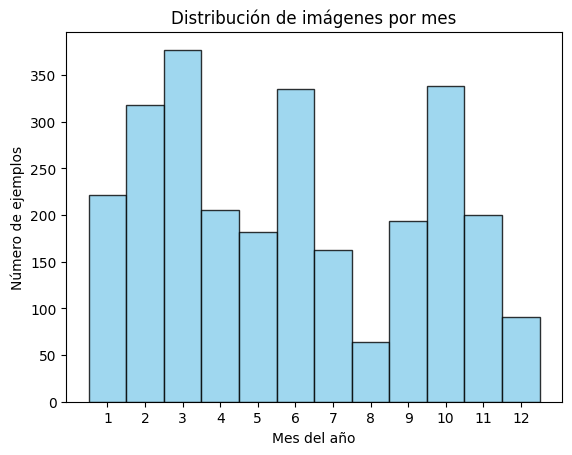

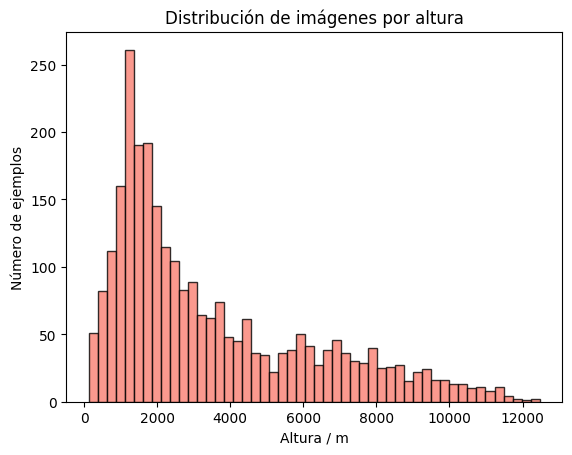

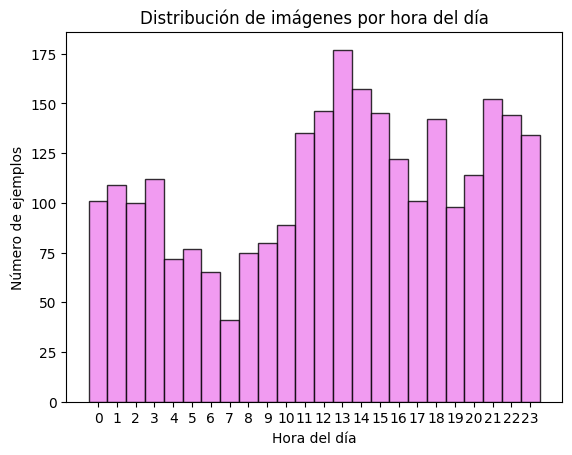

In [ ]:
meses = [fila[0] for fila in datos]
alturas = [fila[4] for fila in datos]
horas = [fila[2] for fila in datos]


plt.figure()
plt.hist(meses, bins=np.arange(0.5, 13.5, 1), edgecolor='black', color='skyblue', alpha=0.8)
plt.title('Distribución de imágenes por mes')
plt.xlabel('Mes del año')
plt.ylabel('Número de ejemplos')
plt.xticks(range(1, 13))
plt.show()

plt.figure()
plt.hist(alturas, bins=50, edgecolor='black', color='salmon', alpha=0.8) #bins=cantidad de barras
plt.title('Distribución de imágenes por altura')
plt.xlabel('Altura / m')
plt.ylabel('Número de ejemplos')
plt.show()

plt.figure()
plt.hist(horas, bins=np.arange(-0.5, 24.5, 1), edgecolor='black', color='violet', alpha=0.8) #bins=cantidad de barras
plt.title('Distribución de imágenes por hora')
plt.xlabel('Hora del día')
plt.ylabel('Número de ejemplos')
plt.xticks(range(0, 24))
plt.show()

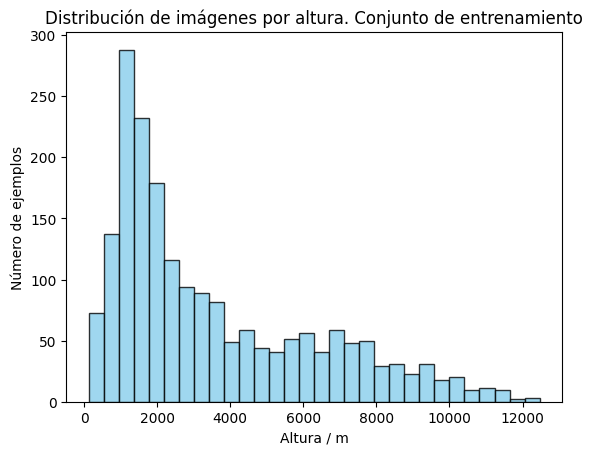

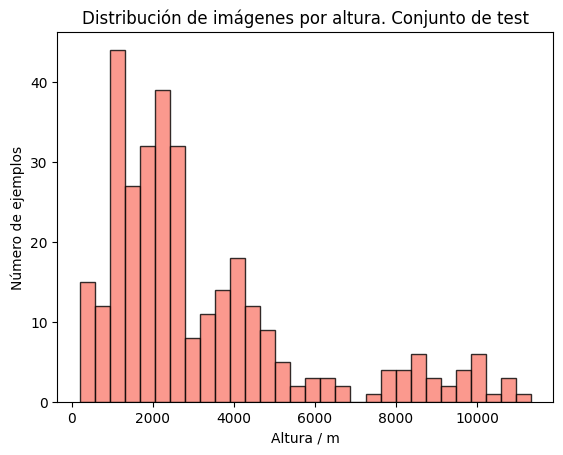

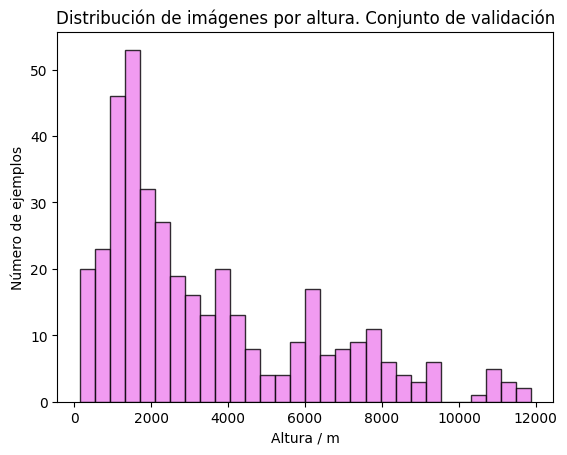

In [49]:
alturas_train = [fila[4] for fila in train]
alturas_test = [fila[4] for fila in test]
alturas_val = [fila[4] for fila in val]


numbins=30

plt.figure()
plt.hist(alturas_train, bins=numbins, edgecolor='black', color='skyblue', alpha=0.8) #bins=cantidad de barras
plt.title('Distribución de imágenes por altura. Conjunto de entrenamiento')
plt.xlabel('Altura / m')
plt.ylabel('Número de ejemplos')
plt.show()

plt.figure()
plt.hist(alturas_test, bins=numbins, edgecolor='black', color='salmon', alpha=0.8) #bins=cantidad de barras
plt.title('Distribución de imágenes por altura. Conjunto de test')
plt.xlabel('Altura / m')
plt.ylabel('Número de ejemplos')
plt.show()

plt.figure()
plt.hist(alturas_val, bins=numbins, edgecolor='black', color='violet', alpha=0.8) #bins=cantidad de barras
plt.title('Distribución de imágenes por altura. Conjunto de validación')
plt.xlabel('Altura / m')
plt.ylabel('Número de ejemplos')
plt.show()